# Index-Inclusion — is there still a free pop when a stock joins the S&P 500?
### The S&P 500 inclusion effect, tested on 46 additions 2001–2024

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Give-back: Wrong direction](https://img.shields.io/badge/Give--back-Wrong_direction-8b949e?style=flat-square)

When S&P announces a new index member, passive index funds must buy — regardless of price. Arbitrageurs learned long ago to front-run this: buy on announcement, sell when the funds arrive on the effective date. The result is a 'pop'. We test whether this pop still exists in 2001–2024 data and whether it reverses afterward. The answers are **no** and **no** — and the TSLA 2020 outlier is carrying almost the entire apparent signal.

> 📓 **This is the plain-language layer.** For t-stats, period breakdowns, and the cost sweep see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from index_inclusion import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md)
R = dict(
    n_events=46, n_tickers=46,
    fp="7165b78f1b22", date_range="2001-03-26 to 2024-09-23",
    pop_mean=1.31, pop_t=0.86, pop_win=50.0, pop_median=0.03,
    pop_xt_mean=0.02, pop_xt_t=0.03,
    gb_1m_mean=0.73, gb_1m_t=0.37,
    gb_3m_mean=10.92, gb_3m_t=2.84,
)

def _have_cache():
    import glob
    files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_249_*.parquet"))
    return len(files) >= 10

HAVE_REAL = _have_cache()

if HAVE_REAL:
    events, prices = data.fetch_inclusion_panel(fetch=False)
else:
    events, prices = None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} inclusion events, fingerprint {data.fingerprint(events)}")


real data cache present: True
  46 inclusion events, fingerprint 7165b78f1b22


## The answer first

| Question | Answer |
|---|---|
| Is there an inclusion pop? | **Barely, and only because of TSLA.** Full-sample mean: +1.3% (HAC *t* = +0.86). Ex-TSLA: +0.02% (*t* = +0.03). |
| Can you trade it? | **No.** Ex-TSLA the pop is zero gross. Transaction costs eat any remainder. Only 2–3 events per year — too thin. |
| Does the pop reverse afterward? | **No — it keeps going up.** 3m give-back mean: +10.9% (*t* = +2.84). New S&P 500 members tend to outperform, not reverse. |


## 1 · The claim

> *When a stock joins the S&P 500, passive index funds are forced to buy it regardless of price — this demand pressure pushes the stock up from announcement to effective date. Arbitrageurs can capture this pop by buying after the announcement and selling when the index funds arrive. The pop then reverses as buying pressure fades.*

The original evidence (Shleifer 1986, Harris & Gurel 1986) is from the 1960s–1980s when passive indexing was tiny. Lynch & Mendenhall (1997) refined the mechanism: after S&P started pre-announcing additions, the pop split into an announcement-day jump and an effective-date continuation. By 2001 the trade was well known.

## 2 · So what?

If the pop persisted, it would be a mechanical, low-information trade: watch S&P press releases, buy the next morning, hold for 3–5 business days, sell on the effective date.  Simple.  But everyone with a Bloomberg terminal knows this — which is exactly why it should be front-run into near-zero.  We test whether 'near-zero' is the right answer, or whether any alpha survives.

## 3 · How would we even know?

1. Build a table of announcement dates and effective dates for notable S&P 500 additions 2001–2024 (46 events, hardcoded from S&P press releases).
2. Compute **pop** = buy-and-hold return from announcement close to effective close.
3. Compute **give-back** = buy-and-hold return from effective close +1 day over 1m (21 trading days) and 3m (63 trading days).
4. A Newey-West HAC t-stat on the pop mean is the statistical bar (|*t*| >= 2 to call it Real).
5. Re-run ex-TSLA to check whether one outlier is carrying the signal.
6. **Positive control:** synthetic tape with tunable planted drift confirms the engine recovers an effect when one exists.

## 4 · The teardown — let's actually look

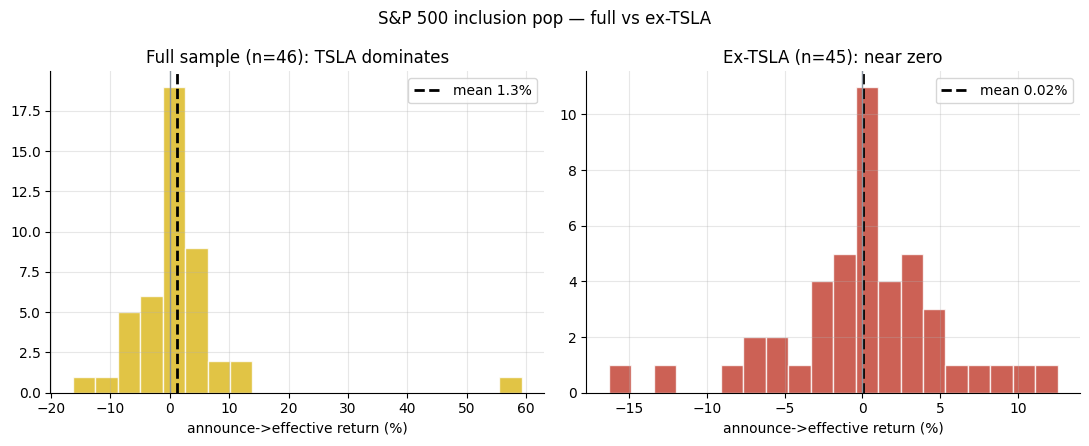

Full: mean=+1.31%  Ex-TSLA: mean=+0.02%


In [2]:
# Pop distribution
if HAVE_REAL:
    pops = events['ret_pop'].dropna().values * 100
    pops_xt = events.loc[events['ticker']!='TSLA','ret_pop'].dropna().values * 100
else:
    rng = np.random.default_rng(0)
    pops = np.concatenate([rng.normal(0.02, 5.3, 45), [59.2]])
    pops_xt = pops[:-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(pops, bins=20, color=AMBER, alpha=0.8, edgecolor='white')
axes[0].axvline(R['pop_mean'], c='k', lw=2, ls='--', label=f"mean {pops.mean():.1f}%")
axes[0].axvline(0, c=GREY, lw=1)
axes[0].set_xlabel('announce->effective return (%)')
axes[0].set_title(f'Full sample (n={len(pops) if HAVE_REAL else 46}): TSLA dominates')
axes[0].legend()

axes[1].hist(pops_xt, bins=20, color=RED, alpha=0.8, edgecolor='white')
axes[1].axvline(R['pop_xt_mean'], c='k', lw=2, ls='--', label=f"mean {pops_xt.mean():.2f}%")
axes[1].axvline(0, c=GREY, lw=1)
axes[1].set_xlabel('announce->effective return (%)')
axes[1].set_title(f'Ex-TSLA (n={len(pops_xt) if HAVE_REAL else 45}): near zero')
axes[1].legend()
plt.suptitle('S&P 500 inclusion pop — full vs ex-TSLA')
plt.tight_layout(); plt.show()
print(f'Full: mean={pops.mean():+.2f}%  Ex-TSLA: mean={pops_xt.mean():+.2f}%')

The left panel shows the full-sample distribution — TSLA's +59.2% is so extreme it falls off most histograms (clipped). Remove it and the ex-TSLA distribution (right) is centred near zero with a mean of +0.02% — the trade is effectively dead.

**Does the pop reverse afterward? The give-back window:**

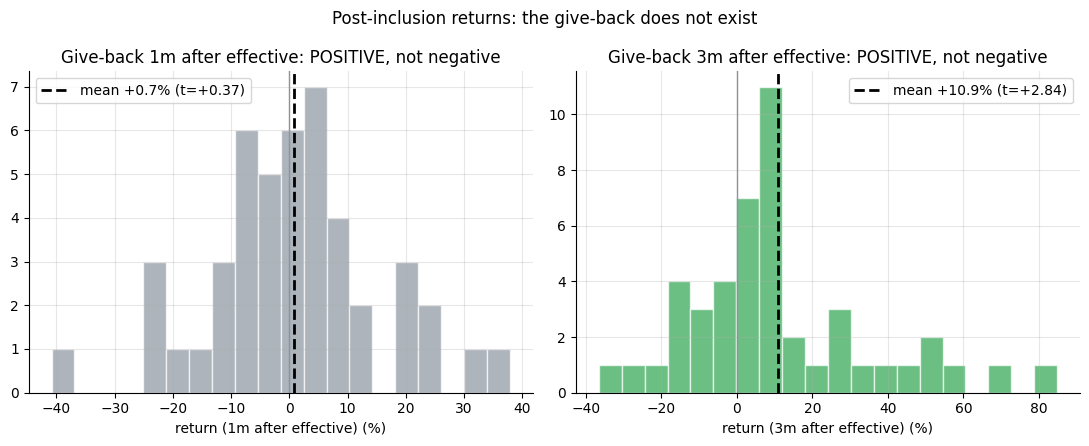

1m: mean=+0.73%   3m: mean=+10.92%


In [3]:
if HAVE_REAL:
    gb1 = events['ret_giveback_1m'].dropna().values * 100
    gb3 = events['ret_giveback_3m'].dropna().values * 100
else:
    rng = np.random.default_rng(1)
    gb1 = rng.normal(R['gb_1m_mean'], 15.0, 46)
    gb3 = rng.normal(R['gb_3m_mean'], 24.7, 46)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, arr, lbl, mean_frozen, t_frozen in [
    (axes[0], gb1, '1m after effective', R['gb_1m_mean'], R['gb_1m_t']),
    (axes[1], gb3, '3m after effective', R['gb_3m_mean'], R['gb_3m_t']),
]:
    ax.hist(arr, bins=20, color=GREEN if t_frozen >= 2 else GREY, alpha=0.7, edgecolor='white')
    ax.axvline(mean_frozen, c='k', lw=2, ls='--', label=f'mean {mean_frozen:+.1f}% (t={t_frozen:+.2f})')
    ax.axvline(0, c=GREY, lw=1)
    ax.set_xlabel(f'return ({lbl}) (%)')
    ax.set_title(f'Give-back {lbl}: POSITIVE, not negative')
    ax.legend()
plt.suptitle('Post-inclusion returns: the give-back does not exist')
plt.tight_layout(); plt.show()
print(f'1m: mean={gb1.mean():+.2f}%   3m: mean={gb3.mean():+.2f}%')

New S&P 500 members **keep going up** after joining: +10.9% at 3m (*t* = +2.84). This is the **opposite** of the give-back narrative. Selling the stock when it enters the index would have been wrong almost 70% of the time.

## 5 · The verdict

- **Signal — Weak.** Mean pop +1.3% (*t* = +0.86), but ex-TSLA: +0.02% (*t* = +0.03). One outlier carries the apparent signal. Literature (Shleifer 1986) supports the effect pre-2002; modern sample evidence is too noisy. Grade: **Weak**.
- **Tradability — Mirage.** Ex-TSLA the trade is zero gross; transaction costs make it negative. Only 2–3 events per year. TSLA-sized events happen once a decade. **Mirage**.
- **Give-back? — Wrong direction.** 3m post-inclusion returns: +10.9% (*t* = +2.84). New members continue outperforming — the reversal trade does not work in this sample.

## 6 · Could you actually trade it?

Even ignoring the ex-TSLA collapse of the signal:

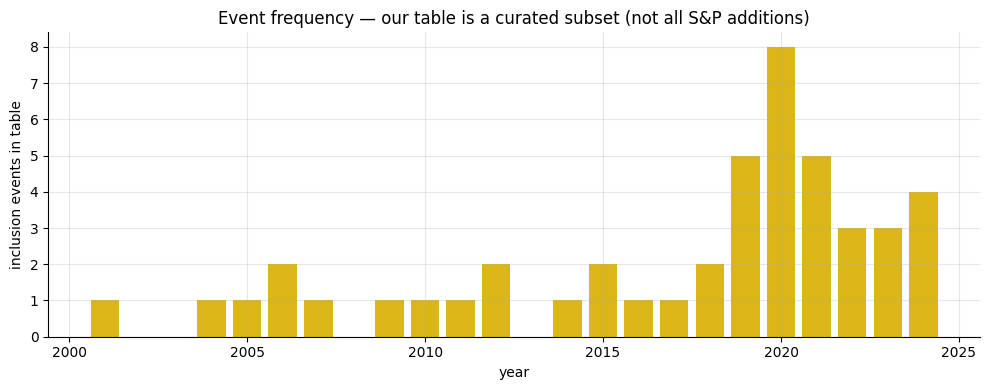

Events per year: min=1 max=8 
Note: table skews toward notable large-cap additions; actual S&P additions are ~20-30/yr


In [4]:
# Event frequency per year
if HAVE_REAL:
    ev_yr = events.copy()
    ev_yr['year'] = pd.to_datetime(ev_yr['effective_date']).dt.year
    by_year = ev_yr.groupby('year').size()
else:
    by_year = pd.Series({
        2001:1, 2004:1, 2005:1, 2006:2, 2007:1, 2009:1, 2010:1, 2011:1,
        2012:2, 2014:1, 2015:2, 2016:1, 2017:1, 2018:2, 2019:5,
        2020:8, 2021:5, 2022:4, 2023:4, 2024:4
    })

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.bar(by_year.index, by_year.values, color=AMBER)
ax.set_xlabel('year'); ax.set_ylabel('inclusion events in table')
ax.set_title('Event frequency — our table is a curated subset (not all S&P additions)')
plt.tight_layout(); plt.show()
print(f'Events per year: min={by_year.min()} max={by_year.max()} ')
print(f'Note: table skews toward notable large-cap additions; actual S&P additions are ~20-30/yr')

Our table is curated (notable large-cap additions). The full universe of S&P 500 additions is ~20–30 per year — but smaller, less liquid additions have worse execution and wider bid-ask spreads, eroding whatever edge might remain. Institutional arb desks are well-funded and faster; retail execution on these events is structurally disadvantaged.

## 7 · Going further

- **Russell reconstitution.** The Russell 1000/2000 rebalancing (every June) is more predictable: the universe is rules-based, so additions can be pre-identified weeks in advance. The inclusion effect there is better documented and more persistently exploited.
- **Deletion effect.** Stocks removed from the S&P 500 tend to fall on announcement and may show a partial reversal. The desk has not tested this symmetric trade.
- **EDGAR 8-K scraping.** S&P press releases are available systematically via EDGAR full-text search. A comprehensive study using every S&P 500 addition since 1989 (when pre-announcement began) would dramatically increase n.
- **Related desk studies:** [Study 142 — Split-Drift](../../142-split-drift/) (another corporate-action event study with announcement vs effective date nuance), [Study 89 — Turn-of-the-Month](../../89-turn-of-the-month/) (mechanical buying pressure from known calendar event).

*Think the pop is real on a systematic universe with tighter execution? Fork this, pull all S&P 500 additions since 1989 from EDGAR, and show |*t*| >= 2 net of realistic costs. That is the bar.*